# An optimal first-order method for smooth and strongly convex composite optimization and its stationary limit

The following code uses [AutoLyap](https://autolyap.github.io/) [1] to validate the finite-horizon Prox-ITEM distance bound from [2].

> [1] Manu Upadhyaya, Shuvomoy Das Gupta, Adrien B. Taylor, Sebastian Banert, and Pontus Giselsson.  
> "[The AutoLyap software suite for computer-assisted Lyapunov analyses of first-order methods](https://arxiv.org/abs/2506.24076)," arXiv:2506.24076, 2025.

> [2] Manu Upadhyaya, Daniel Berg Thomsen, Aymeric Dieuleveut, and Adrien B. Taylor.  
> "[An optimal first-order method for smooth and strongly convex composite optimization and its stationary limit](https://arxiv.org/abs/2605.22929)," arXiv:2605.22929, 2026.

## Authors

- [Manu Upadhyaya](https://manuupadhyaya.github.io/)
- [Daniel Berg Thomsen](https://bergthomsen.com/)
- [Aymeric Dieuleveut](http://www.cmap.polytechnique.fr/~aymeric.dieuleveut/)
- [Adrien Taylor](https://www.di.ens.fr/~ataylor/)

## Problem setup

Consider

$$
\underset{x \in \mathcal{H}}{\operatorname{minimize}}\; f(x)+g(x),
$$

where $\mathcal{H}$ is a real Hilbert space, $f \in \mathcal{F}_{\mu,L}(\mathcal{H})$ with $0<\mu<L$, and $g \in \mathcal{F}_{0,\infty}(\mathcal{H})$.

Initialize $q=\mu/L$, $A_0=0$, and $z^0=x^0$. Prox-ITEM uses

$$
\begin{aligned}
A_{k+1}
&=
\frac{(1+q)A_k+2\left(1+\sqrt{(1+A_k)(1+qA_k)}\right)}{(1-q)^2},\\
\beta_k
&=
\frac{A_k}{(1-q)A_{k+1}},\\
\delta_k
&=
\sqrt{\frac{A_{k+1}}{1+qA_{k+1}}},
\end{aligned}
$$

and the iteration

$$
\begin{aligned}
y^k
&=(1-\beta_k)z^k+\beta_k x^k,\\
\bar z^{k+1}
&=(1-q\delta_k)z^k+q\delta_k y^k-\frac{\delta_k}{L}\nabla f(y^k),\\
z^{k+1}
&=\operatorname{Prox}^{\delta_k/L}_g(\bar z^{k+1}),\\
x^{k+1}
&=y^k-\frac{1}{L}\nabla f(y^k)-\frac{1}{\delta_k}(\bar z^{k+1}-z^{k+1}).
\end{aligned}
$$

The paper gives the finite-horizon bound

$$
\|z^K-x^\star\|^2
\le
\frac{1}{1+qA_K}\|x^0-x^\star\|^2.
$$

In [9]:
%pip install -q autolyap matplotlib

import warnings

import matplotlib.pyplot as plt
import numpy as np

from autolyap import SolverOptions
from autolyap.algorithms import Algorithm
from autolyap.iteration_dependent import IterationDependent
from autolyap.problemclass import Convex, InclusionProblem, SmoothStronglyConvex

warnings.filterwarnings(
    "ignore",
    message="Solution may be inaccurate.*",
    category=UserWarning,
)

def mosek_fusion_is_available():
    try:
        import mosek
        import mosek.fusion  # noqa: F401
    except ImportError:
        return False

    try:
        env = mosek.Env()
    except Exception:
        return False

    checked_out = []
    try:
        for feature in (mosek.feature.pts, mosek.feature.pton):
            env.checkoutlicense(feature)
            checked_out.append(feature)
        return True
    except Exception:
        return False
    finally:
        for feature in reversed(checked_out):
            try:
                env.checkinlicense(feature)
            except Exception:
                pass


def get_solver_options():
    if mosek_fusion_is_available():
        return SolverOptions(backend="mosek_fusion")
    return SolverOptions(backend="cvxpy", cvxpy_solver="CLARABEL")


Note: you may need to restart the kernel to use updated packages.


## State-space representation

Match AutoLyap's [algorithm representation](https://autolyap.github.io/theory/algorithm_representation/) used by the [`Algorithm` API](https://autolyap.github.io/base_algorithms/):

$$
\begin{aligned}
\mathbf{x}^{k+1} &= (A_k\otimes \operatorname{Id})\mathbf{x}^k + (B_k\otimes \operatorname{Id})\mathbf{u}^k,\\
\mathbf{y}^k &= (C_k\otimes \operatorname{Id})\mathbf{x}^k + (D_k\otimes \operatorname{Id})\mathbf{u}^k,
\end{aligned}
$$

where

$$
\begin{aligned}
\mathbf{x}^k &= (x^k,z^k),\\
\mathbf{u}^k &= (\nabla f(y^k),s_g^{k+1}),\\
\mathbf{y}^k &= (y^k,z^{k+1}),
\end{aligned}
$$

with

$$
s_g^{k+1}=L\delta_k^{-1}(\bar z^{k+1}-z^{k+1})\in \partial g(z^{k+1}).
$$

Using $\mathbf{u}^k=(u_1^k,u_2^k)=(\nabla f(y^k),s_g^{k+1})$, the update becomes

$$
\begin{aligned}
x^{k+1}
&=
\beta_k x^k+(1-\beta_k)z^k
-\frac{1}{L}u_1^k
-\frac{1}{L}u_2^k,\\
z^{k+1}
&=
q\delta_k\beta_k x^k
+(1-q\delta_k\beta_k)z^k
-\frac{\delta_k}{L}u_1^k
-\frac{\delta_k}{L}u_2^k,\\
y^k
&=
\beta_k x^k+(1-\beta_k)z^k.
\end{aligned}
$$

In [10]:
class ProxITEM(Algorithm):
    def __init__(self, mu, L, K):
        super().__init__(n=2, m=2, m_bar_is=[1, 1], I_func=[1, 2], I_op=[])
        if not 0 < mu < L:
            raise ValueError("Require 0 < mu < L.")
        self.mu = mu
        self.L = L
        self.A = [0.0]
        # The endpoint constructors query local matrices at k=K.
        for _ in range(K + 1):
            self.A.append(
                (
                    (1.0 + self.q) * self.A[-1]
                    + 2.0 * (1.0 + np.sqrt((1.0 + self.A[-1]) * (1.0 + self.q * self.A[-1])))
                )
                / (1.0 - self.q) ** 2
            )

    @property
    def q(self):
        return self.mu / self.L

    def beta(self, k):
        return self.A[k] / ((1.0 - self.q) * self.A[k + 1])

    def delta(self, k):
        return np.sqrt(self.A[k + 1] / (1.0 + self.q * self.A[k + 1]))

    def rate(self, k):
        return 1.0 / (1.0 + self.q * self.A[k])

    def get_ABCD(self, k):
        return (
            np.array([
                [self.beta(k), 1.0 - self.beta(k)],
                [self.q * self.delta(k) * self.beta(k), 1.0 - self.q * self.delta(k) * self.beta(k)],
            ]),
            np.array([
                [-1.0 / self.L, -1.0 / self.L],
                [-self.delta(k) / self.L, -self.delta(k) / self.L],
            ]),
            np.array([
                [self.beta(k), 1.0 - self.beta(k)],
                [self.q * self.delta(k) * self.beta(k), 1.0 - self.q * self.delta(k) * self.beta(k)],
            ]),
            np.array([
                [0.0, 0.0],
                [-self.delta(k) / self.L, -self.delta(k) / self.L],
            ]),
        )


## AutoLyap Lyapunov sweep

Following AutoLyap's [iteration-dependent analysis](https://autolyap.github.io/theory/iteration_dependent_analyses/) ([API](https://autolyap.github.io/iteration_dependent_analysis/)), we search for the smallest finite-horizon scalar $c_K$ such that

$$
\|z^K-x^\star\|^2\le c_K\|x^0-x^\star\|^2.
$$

The target value is

$$
c_K^\mathrm{theory}=\frac{1}{1+qA_K}.
$$

In [11]:
K_values = np.arange(1, 11)
q_value = 0.25
L_value = 1.0
mu_value = q_value * L_value
solver_options = get_solver_options()

problem = InclusionProblem([
    SmoothStronglyConvex(mu_value, L_value),
    Convex(),
])

c_autolyap_values = []
c_theory_values = []

for K in K_values:
    algorithm = ProxITEM(mu=mu_value, L=L_value, K=int(K))
    Q_0, q_0 = IterationDependent.get_parameters_state_component_distance_to_solution(
        algorithm,
        k=0,
        ell=2,
    )
    Q_K, q_K = IterationDependent.get_parameters_state_component_distance_to_solution(
        algorithm,
        k=int(K),
        ell=2,
    )
    result = IterationDependent.search_lyapunov(
        problem,
        algorithm,
        K=int(K),
        Q_0=Q_0,
        Q_K=Q_K,
        q_0=q_0,
        q_K=q_K,
        solver_options=solver_options,
        verbosity=0,
    )
    if result["status"] != "feasible":
        raise RuntimeError(f"No feasible certificate for K={K}.")

    c_autolyap_values.append(float(result["c_K"]))
    c_theory_values.append(algorithm.rate(int(K)))
    print(f"Solved K={K}: c_K={result['c_K']:.12g}")

c_autolyap_values = np.array(c_autolyap_values)
c_theory_values = np.array(c_theory_values)


Solved K=1: c_K=0.360000003422
Solved K=2: c_K=0.0994158066427
Solved K=3: c_K=0.0254958413924
Solved K=4: c_K=0.00641501100671
Solved K=5: c_K=0.00160633531594
Solved K=6: c_K=0.000401746744885
Solved K=7: c_K=0.000100478479454
Solved K=8: c_K=2.51287468866e-05
Solved K=9: c_K=6.29072064597e-06
Solved K=10: c_K=1.57444752482e-06


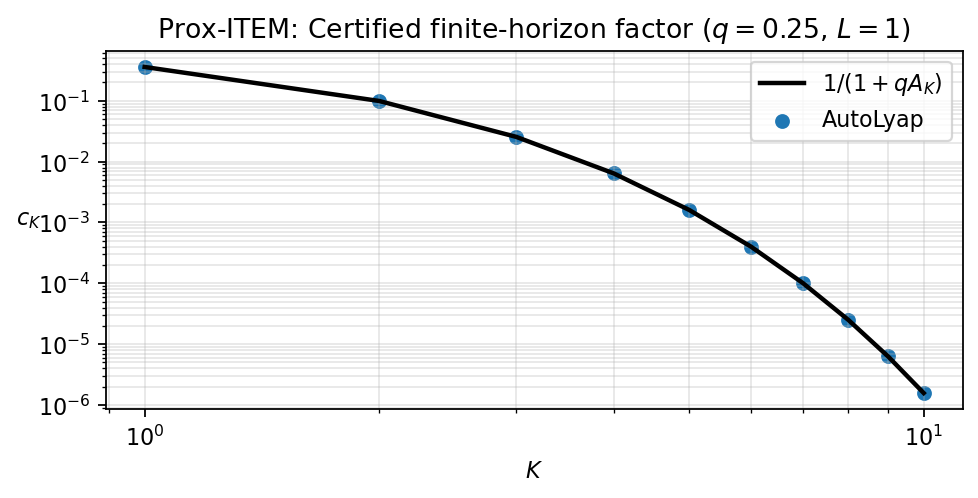

In [12]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=160, constrained_layout=True)
ax.loglog(K_values, c_theory_values, color="black", linewidth=2.0, label="$1/(1+qA_K)$")
ax.scatter(K_values, c_autolyap_values, s=32, color="#1f77b4", label="AutoLyap")
ax.set_xlabel("$K$")
ax.set_ylabel("$c_K$", rotation=0)
ax.set_title(rf"Prox-ITEM: Certified finite-horizon factor ($q={q_value:g}$, $L={L_value:g}$)")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
plt.show()
